<p style="font-size:1.5rem;">Import Libraries</p>

In [1]:
import numpy as np
import pandas as pd
import missingno as msno

import matplotlib.pyplot as plt
import seaborn as sns
# import plotly.express as px

In [2]:
sns.set_style("dark")

# Problem Definition

<p style="font-size:1.5rem; margin-bottom:0.5em;">Objective</p>
<p style="margin-bottom:2rem">Estimate the causal effect of flight delays (departure and arrival) on passenger satisfaction.</p>

<p style="font-size:1.5rem; margin-bottom:0.5rem">Approach</p>
<p>Use the causal inference technique to estimate the effect of delays on satisfaction, controlling for other factors like travel class, type of travel, and flight distance.</p>

In [3]:
# Load data
df_satisfaction = pd.read_csv("../data/raw/airline_passenger_satisfaction.csv")

# Get the shape of the dataset
print("Shape of the dataset:", df_satisfaction.shape)

# Get the head of the dataset
print("\nFirst 5 rows of the dataset:")
df_satisfaction.head()

Shape of the dataset: (129880, 24)

First 5 rows of the dataset:


,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


# Exploratory Data Analysis

<p>
The Exploratory Data Analysis (EDA) section examines the airline satisfaction dataset to explore its characteristics, detect patterns, and extract meaningful insights that guide the modeling process. In this project, the following aspects are taken into account during EDA:
</p>
<ol>
    <li>Identify potential data quality issues that require addressing.</li>
    <li>Generate tables and/or charts that illustrate insights.</li>
    <li>Discover patterns and trends that can guide feature engineering and model selection.</li>
</ol>

## Overview

In [4]:
# Get the information about the dataset
print("\nInformation about the dataset:")
print(df_satisfaction.info())


Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Onli

In [5]:
# Get the data type of each column in the dataframe
print("\nData type of each column in the dataset:")
print(df_satisfaction.dtypes)


Data type of each column in the dataset:
ID                                          int64
Gender                                     object
Age                                         int64
Customer Type                              object
Type of Travel                             object
Class                                      object
Flight Distance                             int64
Departure Delay                             int64
Arrival Delay                             float64
Departure and Arrival Time Convenience      int64
Ease of Online Booking                      int64
Check-in Service                            int64
Online Boarding                             int64
Gate Location                               int64
On-board Service                            int64
Seat Comfort                                int64
Leg Room Service                            int64
Cleanliness                                 int64
Food and Drink                              int64
In-fligh

In [6]:
# Overview of numeric features
df_satisfaction.describe(exclude=["O"])

,ID,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,64940.500000,39.427957,1190.316392,14.713713,15.091129,3.057599,2.756876,3.306267,3.252633,2.976925,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114
std,37493.270818,15.119360,997.452477,38.071126,38.465650,1.526741,1.401740,1.266185,1.350719,1.278520,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,32470.750000,27.000000,414.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,64940.500000,40.000000,844.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,97410.250000,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,129880.000000,85.000000,4983.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [7]:
# Overview of categorical features
df_satisfaction.describe(include=["O"])

,Gender,Customer Type,Type of Travel,Class,Satisfaction
count,129880,129880,129880,129880,129880
unique,2,2,2,3,2
top,Female,Returning,Business,Business,Neutral or Dissatisfied
freq,65899,106100,89693,62160,73452


## Missingness

In [8]:
# What's percentage of the records are missing per features?
df_satisfaction.isna().mean() * 100

ID                                        0.000000
Gender                                    0.000000
Age                                       0.000000
Customer Type                             0.000000
Type of Travel                            0.000000
Class                                     0.000000
Flight Distance                           0.000000
Departure Delay                           0.000000
Arrival Delay                             0.302587
Departure and Arrival Time Convenience    0.000000
Ease of Online Booking                    0.000000
Check-in Service                          0.000000
Online Boarding                           0.000000
Gate Location                             0.000000
On-board Service                          0.000000
Seat Comfort                              0.000000
Leg Room Service                          0.000000
Cleanliness                               0.000000
Food and Drink                            0.000000
In-flight Service              

<Axes: >

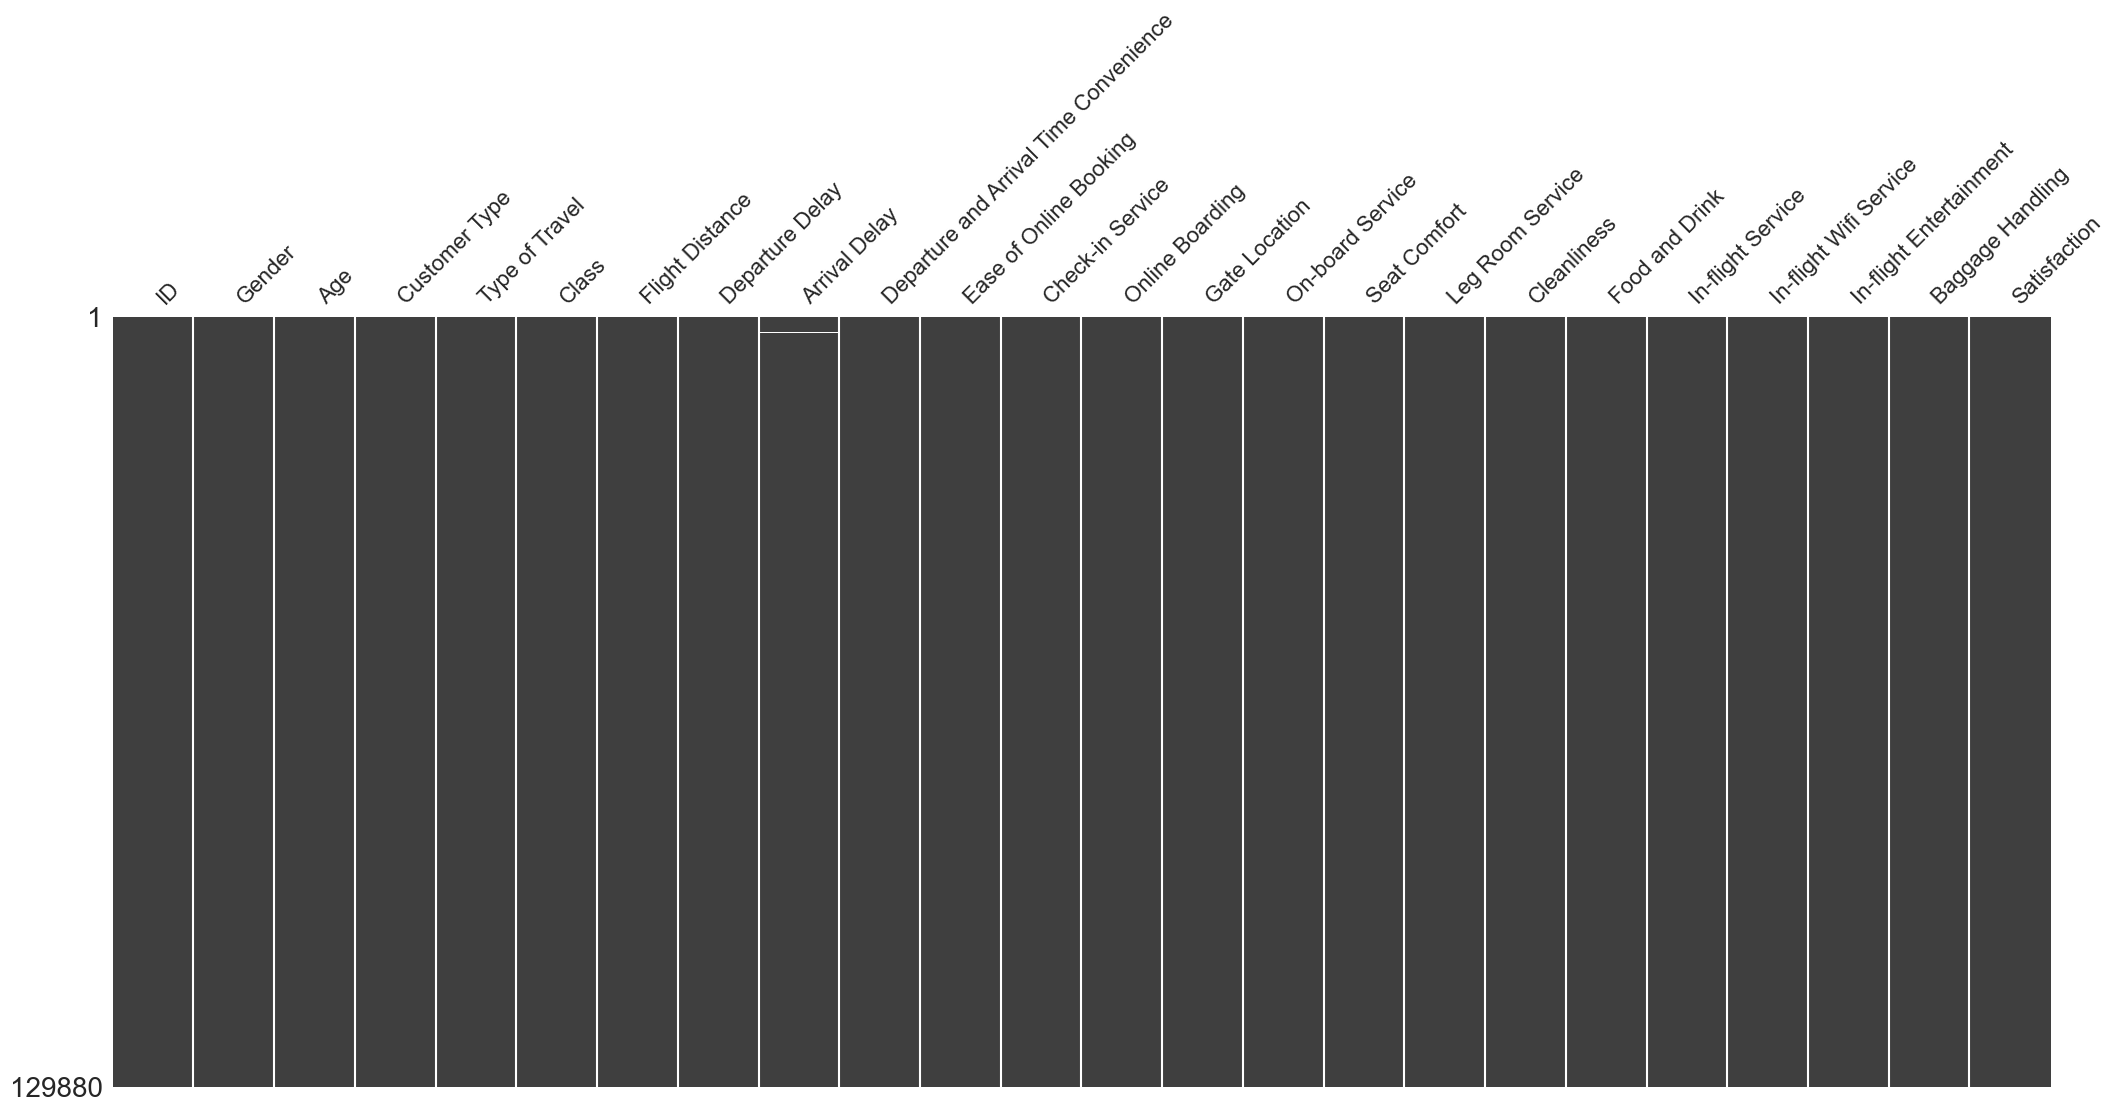

In [9]:
# Visualize missing data
msno.matrix(
    df=df_satisfaction,
    sparkline=False
)

<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">Insights</p>
<p style="margin-bottom:5rem">
Missing data exists only in one column and constitutes only a small proportion (0.303%) of the total data. We have decided to drop these missing values without significantly affecting the overall integrity of the data.
</p>

In [10]:
df_satisfaction.dropna(
    subset=["Arrival Delay"],
    inplace=True, 
    ignore_index=True
)

In [11]:
df_satisfaction.duplicated().sum()

0

## Univariate Analysis

In [12]:
# Distribution of "Satisfaction"
df_satisfaction.value_counts(
    subset=["Satisfaction"], 
    normalize=True,
    ascending=True
) * 100

Satisfaction           
Satisfied                  43.449922
Neutral or Dissatisfied    56.550078
Name: proportion, dtype: float64

<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">Key Insights</p>
<ul style="margin-bottom:5rem">
    <li>The dataset is not heavily imbalanced, but there are more "Neutral or Dissatisfied" customers (56.55%) than "Satisfied" ones (43.45%).</li>
    <li>A higher percentage (56.55%) of unsatisfied customers suggests a need for service improvement.</li>
    <li>Understanding why customers are dissatisfied is crucial for improving customer experience.</li>
</ul>

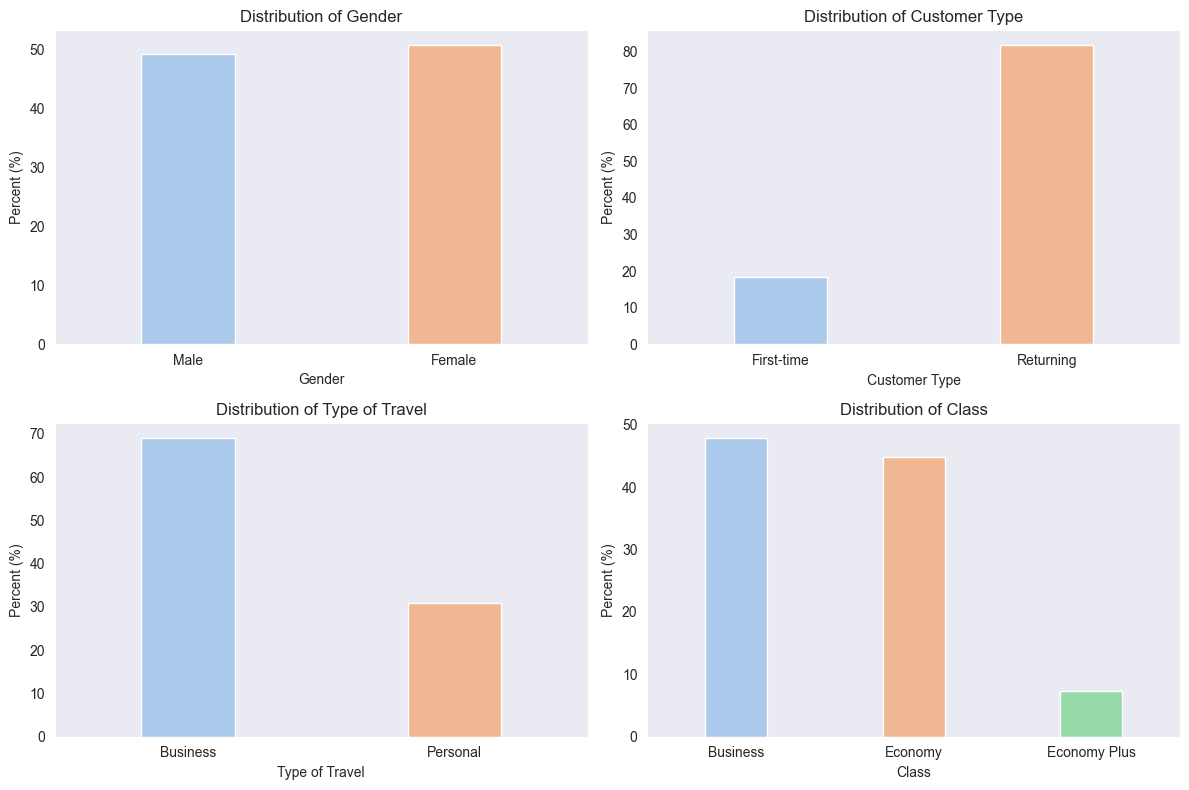

In [13]:
# List of categorical features
cat_features = ["Gender", "Customer Type", "Type of Travel", "Class"]

# Set grid layout (rows & columns)
col_nos = 2  
row_nos = int(np.ceil(len(cat_features) / col_nos)) 

# Create a figure with subplots
fig, axes = plt.subplots(row_nos, col_nos, figsize=(12, 4 * row_nos))

# Flatten axes if more than 1 row, otherwise ensure it's iterable
axes = np.atleast_1d(axes).flatten()

# Iterate through the categorical features and plot dynamically
for i, cat_feature in enumerate(cat_features):
    sns.countplot(
        data=df_satisfaction,
        x=cat_feature,
        ax=axes[i],  
        width=0.35,
        stat="percent",
        hue=cat_feature,  
        legend=False,  # Remove legend since bars are already colored by category
        palette="pastel" 
    )
    
    # Set titles and labels
    axes[i].set_title(f"Distribution of {cat_feature}")
    axes[i].set_ylabel("Percent (%)")
    axes[i].set_xlabel(cat_feature)
    axes[i].tick_params(axis="x", rotation=0) 

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  
plt.show()

<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">Comments on the Categorical Features</p>
<ul style="margin-bottom:5rem">
    <li><strong>Gender: </strong>Nearly balanced distribution, with slightly more female passengers than males. Suggests gender may not heavily bias results, but minor differences in satisfaction by gender might still be insightful.</li>
    <li><strong>Customer Type: </strong>Returning Customers dominate (~80%), while First-time flyers are around 20%. This suggests the airline relies more on returning customers than new ones.</li>
    <li><strong>Type of Travel: </strong>Business Travelers (~70%) dominate, while Personal Travelers (~30%) are fewer. Business travelers may have higher expectations regarding timeliness, comfort, and service quality.</li>
    <li><strong>Class: </strong>Business Class (~50%) and Economy (~45%) are dominant. Economy Plus is significantly lower (~5%), indicating fewer customers in this category.</li>
</ul>

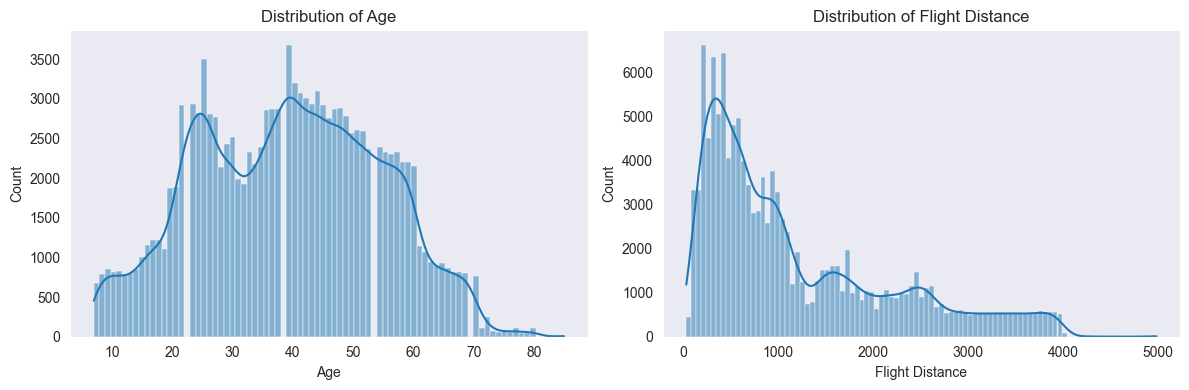

In [14]:
# List of numeric features
num_features = ["Age", "Flight Distance"]

# Set grid layout (rows & columns)
col_nos = 2  
row_nos = int(np.ceil(len(num_features) / col_nos)) 

# Create a figure with subplots
fig, axes = plt.subplots(row_nos, col_nos, figsize=(12, 4 * row_nos))

# Flatten axes if more than 1 row, otherwise ensure it's iterable
axes = np.atleast_1d(axes).flatten()

# Iterate through the numeric features and plot dynamically
for i, num_feature in enumerate(num_features):
    sns.histplot(
        data=df_satisfaction,
        x=num_feature,
        ax=axes[i],  
        kde=True
    )
    
    # Set titles and labels
    axes[i].set_title(f"Distribution of {num_feature}")
    axes[i].set_ylabel("Count")
    axes[i].set_xlabel(num_feature)
    axes[i].tick_params(axis="x", rotation=0) 

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  
plt.show()

<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">Comments on the Numeric Features</p>
<ul style="margin-bottom:5rem">
    <li><strong>Age: </strong>There are two peaks (bimodal), one around 25 years and another near 40 years. There are few younger passengers (<10 years old), possibly indicating family travelers are a minority.</li>
    <li><strong>Flight Distance: </strong>Right-skewed distribution (most flights are short-haul, concentrated below 1,000 km). Peaks at common travel distances, possibly indicating hub airports or popular routes.</li>
</ul>

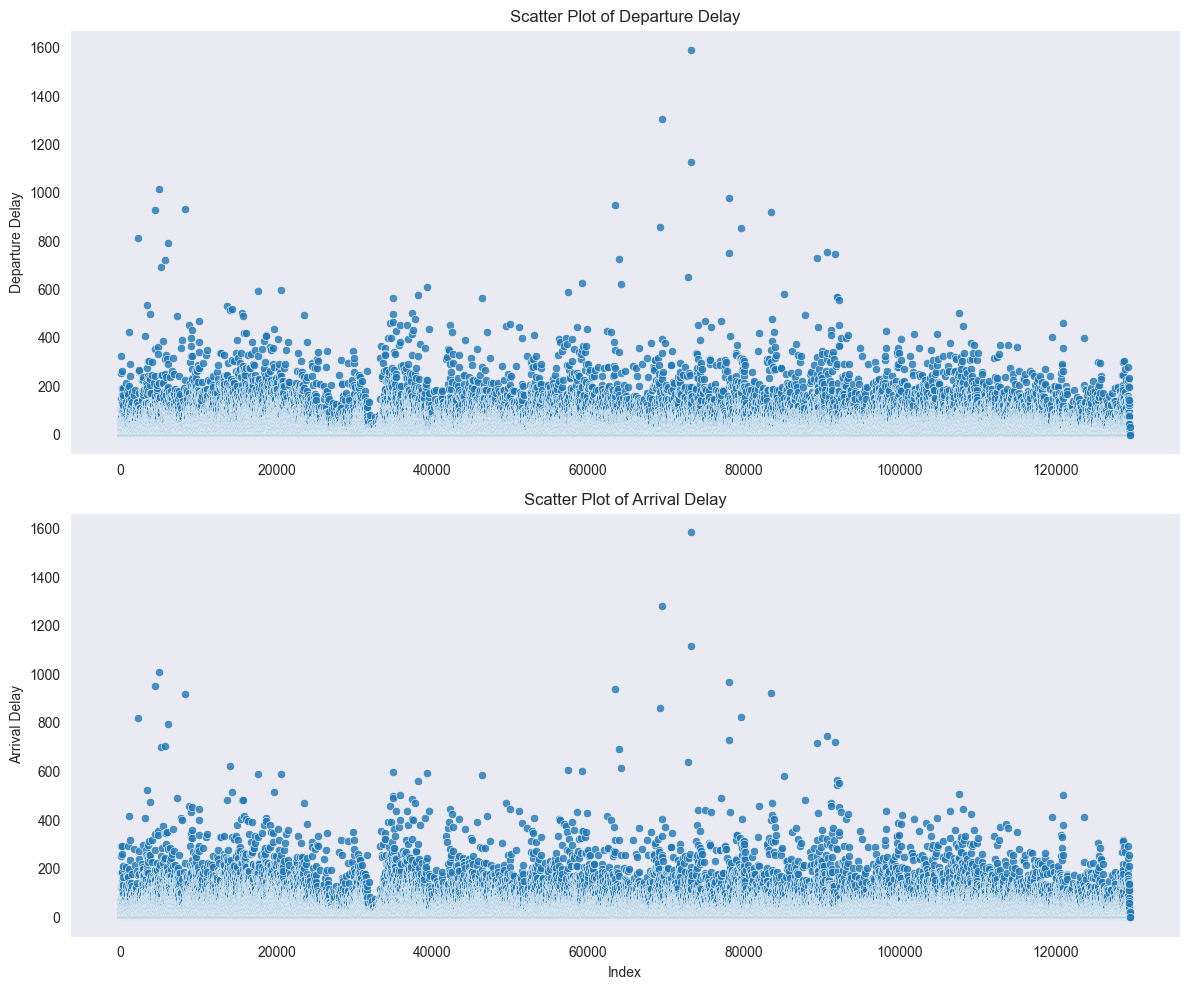

In [15]:
# Distribution of "Departure Delay" and "Arrival Delay" 
delay_features = ["Departure Delay", "Arrival Delay"]

# Create a figure with subplots 
fig, axes = plt.subplots(len(delay_features), 1, figsize=(12, 5 * len(delay_features)))  

# If only one variable, axes might not be iterable, so convert to a list
if len(delay_features) == 1:
    axes = [axes]

# Iterate through the delay features
for i, delay_feature in enumerate(delay_features):
    sns.scatterplot(
        data=df_satisfaction,
        x=df_satisfaction.index,  
        y=delay_feature, 
        alpha=0.8,
        ax=axes[i]  # Assign to correct subplot
    )
    axes[i].set_title(f"Scatter Plot of {delay_feature}")
    axes[i].set_ylabel(delay_feature)
    axes[i].set_xlabel("Index" if i == len(delay_features) - 1 else "")  # Label only the last subplot
    # axes[i].set_yscale("log")  

plt.tight_layout() 
plt.show()

<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">Comments on the Delay (Numeric) Features</p>
<ul style="margin-bottom:1.5rem">
    <li><strong>Departure Delay: </strong>Most departure delays are close to 0 minutes. A small number of extreme outliers (>1,000 minutes) exist. Majority of flights have minimal departure delays, but some severe delays occur.</li>
    <li><strong>Arrival Delay: </strong>Similar to departure delays, mostly near 0 minutes with a few extreme cases.</li>
</ul>

<p style="margin-bottom:5rem"><strong>Note: </strong>Arrival delays are critical for satisfaction—passengers care more about on-time arrivals than departures.</p>

## Mutivariate Analysis

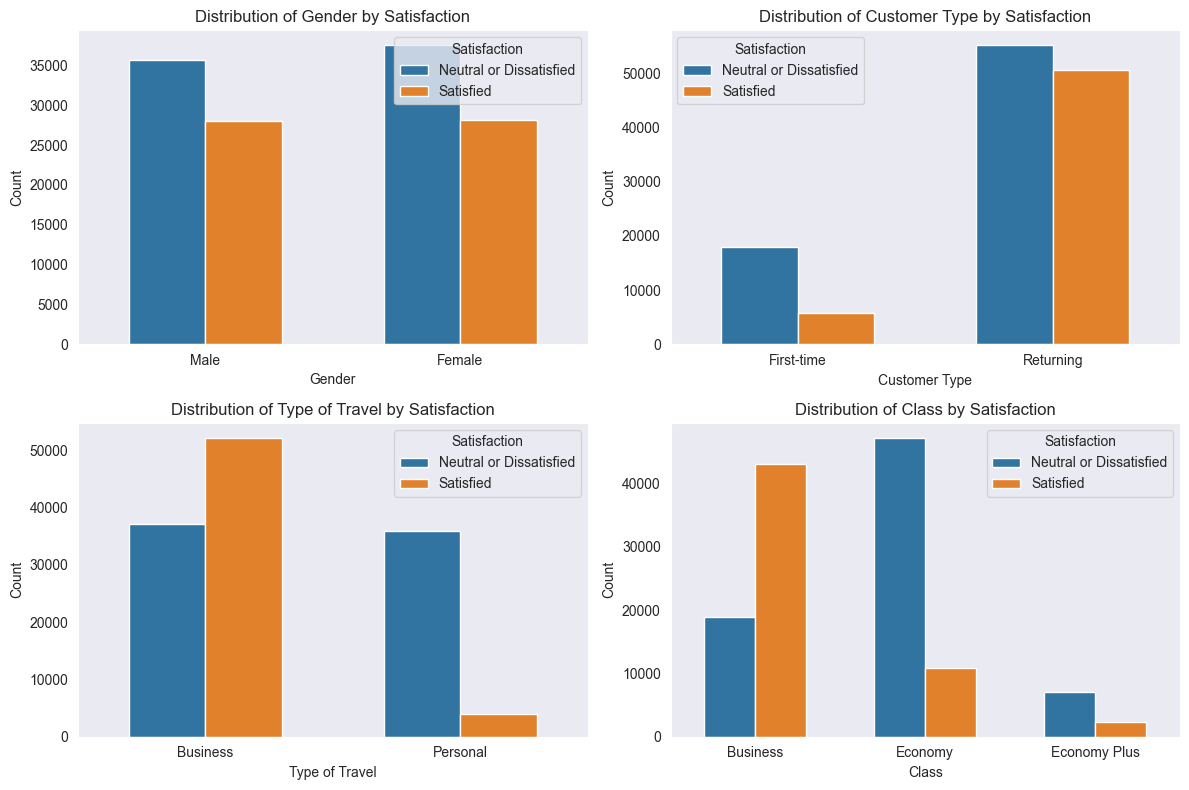

In [16]:
# List of categorical features
cat_features = ["Gender", "Customer Type", "Type of Travel", "Class"]

# Set grid layout (rows & columns)
col_nos = 2  
row_nos = int(np.ceil(len(cat_features) / col_nos)) 

# Create a figure with subplots
fig, axes = plt.subplots(row_nos, col_nos, figsize=(12, 4 * row_nos))

# Flatten axes if more than 1 row, otherwise ensure it's iterable
axes = np.atleast_1d(axes).flatten()

# Iterate through the categorical features and plot dynamically
for i, cat_feature in enumerate(cat_features):
    sns.countplot(
        data=df_satisfaction,
        x=cat_feature,
        hue="Satisfaction",  
        ax=axes[i],
        width=0.6 
    )
    
    # Set titles and labels
    axes[i].set_title(f"Distribution of {cat_feature} by Satisfaction")
    axes[i].set_ylabel("Count")
    axes[i].set_xlabel(cat_feature)
    axes[i].tick_params(axis="x", rotation=0)  # Rotate x-labels for readability

# Hide any unused subplots (if odd number of categories)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:1.5em;">Comments on the Categorical Features by Satisfaction Level</p>
<ul style="margin-bottom:5rem">
    <li><strong>Gender vs. Satisfaction: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>Female and Male passengers have similar satisfaction distributions. More females and males are Neutral/Dissatisfied than satisfied, but the difference is not very large.</li>
            <li>Gender does not appear to be a strong driver of satisfaction differences.</li>
        </ul>
    </li>
        <li><strong>Customer Type vs. Satisfaction: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>Returning customers have a more balanced satisfaction distribution, but a higher count of dissatisfaction. First-time flyers are overwhelmingly Neutral/Dissatisfied, with very few satisfied passengers.</li>
            <li>First-time flyers may have unrealistic expectations or negative initial experiences. Returning customers have mixed experiences, indicating some level of inconsistent service. Airlines should focus on improving first-time experiences to increase retention.</li>
        </ul>
    </li>
    </li>
        <li><strong>Type of Travel vs. Satisfaction: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>Business travelers are mostly satisfied, while personal travelers are mostly dissatisfied. Personal travelers are overwhelmingly Neutral/Dissatisfied, with very few satisfied individuals.</li>
            <li>Business travelers might value time and efficiency more—they are satisfied if their needs are met. Personal travelers might expect more comfort, affordability, or leisure-friendly service, leading to dissatisfaction. Airlines could improve leisure traveler experiences by offering better perks, comfort, and pricing strategies.</li>
        </ul>
    </li>
    </li>
        <li><strong>Class vs. Satisfaction: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>Business class has the highest satisfaction rate. Economy class has the highest dissatisfaction rate, with far more Neutral/Dissatisfied passengers. Economy Plus is the least common class, but also has a higher dissatisfaction rate than Business Class.</li>
            <li>Service quality in Economy Class might be a key issue, leading to lower satisfaction. Business class travelers likely receive better services, contributing to higher satisfaction. Airlines could improve Economy Class experience with better seating, service quality, and in-flight entertainment.</li>
        </ul>
    </li>
</ul>

In [17]:
# Mean delay by satisfaction level for first-time customers
(
    df_satisfaction
    .query("`Customer Type` == 'First-time'")  # Use backticks for column names with spaces
    .groupby("Satisfaction")[["Departure Delay", "Arrival Delay"]]
    .mean()  # Aggregate using mean
)

,Departure Delay,Arrival Delay
Satisfaction,,
Neutral or Dissatisfied,15.700044,16.365639
Satisfied,12.674578,12.654184


<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">Mean Delay by Satisfaction Level for First-Time Customers</p>
<ul style="margin-bottom:5rem">
    <li>Dissatisfied first-time customers experience longer departures and arrival delays. On the other hand, satisfied first-time customers experience shorter delays</li>
    <li>The difference in mean delays is modest but noticeable. Departure delay difference is ~3 minutes (15.7 min vs. 12.67 min), and arrival delay difference is ~3.7 minutes (16.36 min vs. 12.65 min)</li>
    <li>Reducing delays by even 3–4 minutes could significantly improve satisfaction rates.</li>
</ul>

In [18]:
# Mean delay by satisfaction level for personal travelers
(
    df_satisfaction
    .query("`Type of Travel` == 'Personal'")  # Use backticks for column names with spaces
    .groupby("Satisfaction")[["Departure Delay", "Arrival Delay"]]
    .mean()  # Aggregate using mean
)

,Departure Delay,Arrival Delay
Satisfaction,,
Neutral or Dissatisfied,15.102620,15.655848
Satisfied,7.020469,6.769914


<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">Mean Delay by Satisfaction Level for Personal Travelers</p>
<ul style="margin-bottom:5rem">
    <li>Dissatisfied personal travelers experience significantly longer departures and arrival delays. On the other hand, satisfied personal travelers experience shorter delays</li>
    <li>The difference in mean delays is large. Departure delay difference is ~8 minutes (15.10 - 7.02), and arrival delay difference is ~8.9 minutes (15.66 - 6.77)</li>
    <li>Reducing delays by even 8–9 minutes could significantly improve satisfaction rates.</li>
</ul>

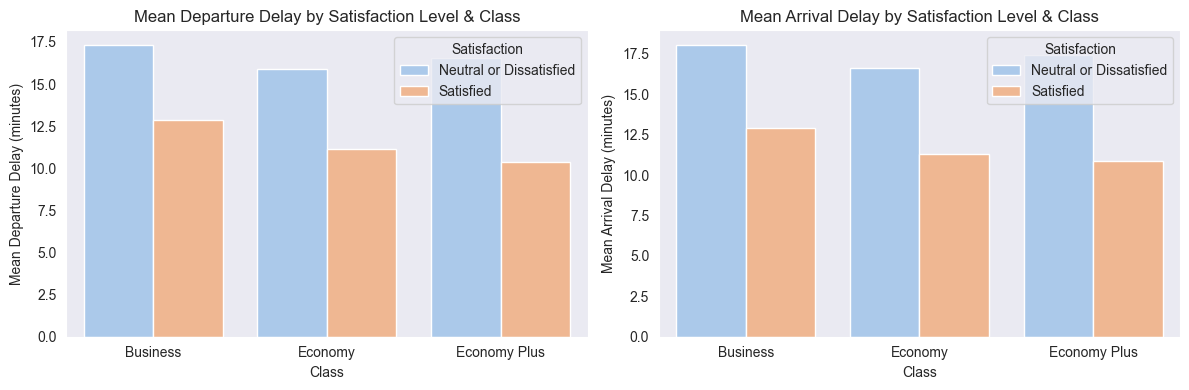

In [19]:
# Compute mean delay by satisfaction level and class
df = (
    df_satisfaction
    .groupby(["Satisfaction", "Class"])[["Departure Delay", "Arrival Delay"]]
    .mean()
    .reset_index()
)

# Dynamically determine the number of subplots (1 row, 2 columns)
delay_features = ["Departure Delay", "Arrival Delay"]
col_nos = len(num_features)

# Create subplots dynamically
fig, axes = plt.subplots(1, col_nos, figsize=(12, 4))

# Loop through delay features and create bar plots
for i, delay_feature in enumerate(delay_features):
    sns.barplot(
        data=df,
        x="Class",
        y=delay_feature,
        hue="Satisfaction",
        ax=axes[i],
        palette="pastel"
    )
    axes[i].set_title(f"Mean {delay_feature} by Satisfaction Level & Class")
    axes[i].set_ylabel(f"Mean {delay_feature} (minutes)")
    axes[i].set_xlabel("Class")
    axes[i].tick_params(axis="x", rotation=0)  # Rotate x-labels for better readability

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">Mean Delay by Satisfaction Level & Class</p>
<ul style="margin-bottom:5rem">
    <li>For every class, Neutral/Dissatisfied passengers have higher average delays compared to Satisfied passengers. This suggests that delays are a major driver of dissatisfaction, regardless of class.</li>
    <li>Satisfied Business Class passengers tend to experience longer average delays compared to satisfied passengers in other classes. This may be attributed to enhanced amenities, priority services, and lounge access, which help offset the inconvenience of delays.</li>
    <li>Economy Class passengers tend to express dissatisfaction even with relatively shorter delays. This could be due to fewer compensations, such as lack of lounge access or limited rebooking options.</li>
</ul>

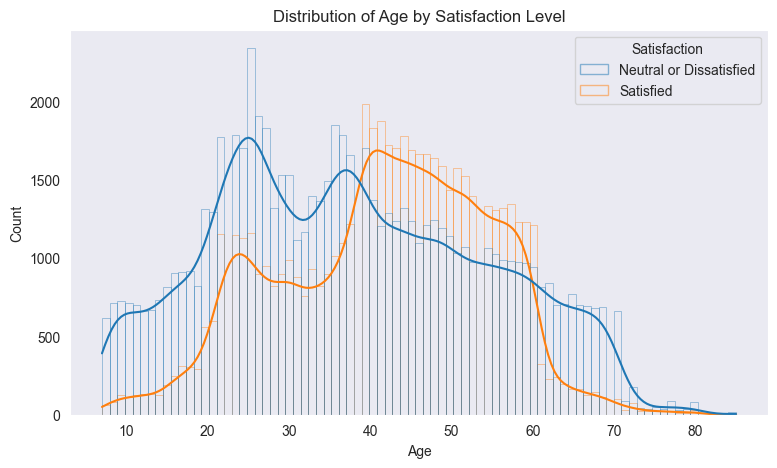

In [20]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_satisfaction,
    x="Age",
    hue="Satisfaction",  # Different colors for Satisfaction levels
    kde=True,  # Overlay KDE (optional for smooth distribution)
    # bins=30,  # Adjust bin count for better granularity
    # element="step",  # Style bars as steps for clarity
    # palette="pastel",  # Improve visibility with soft colors
    fill=False,
    alpha=0.5  # Transparency to see overlapping bars
)

# Set title and labels
plt.title("Distribution of Age by Satisfaction Level")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">Comments on Age by Satisfaction Level</p>
<ul style="margin-bottom:5rem">
    <li>The blue KDE curve (Neutral/Dissatisfied) dominates in the 10-30 age range. This suggests younger passengers have higher dissatisfaction rates compared to older passengers.</li>
    <li>The orange KDE curve (Satisfied) peaks around 40 years old, showing that middle-aged travelers are more satisfied.</li>
</ul>

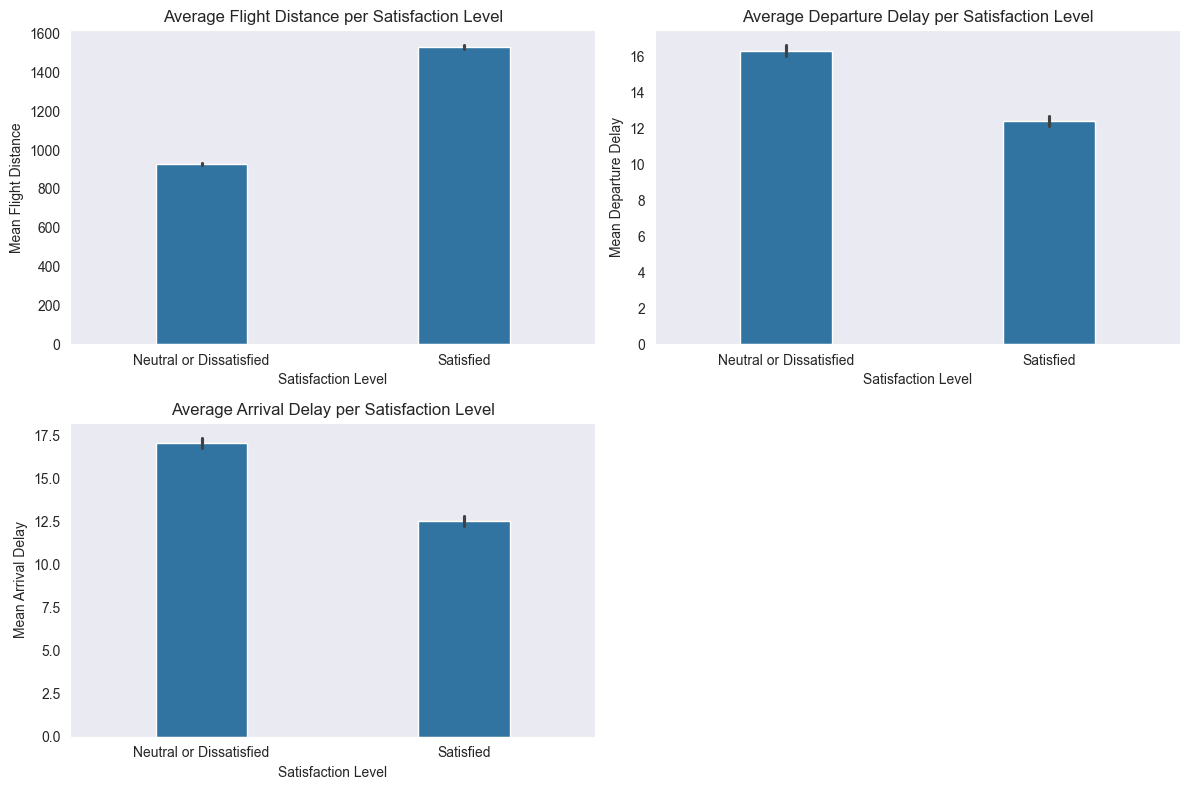

In [21]:
# List of numeric features
num_features = ["Flight Distance", "Departure Delay", "Arrival Delay"]

# Set grid layout (rows & columns)
col_nos = 2  
row_nos = int(np.ceil(len(num_features) / col_nos)) 

# Create a figure with subplots
fig, axes = plt.subplots(row_nos, col_nos, figsize=(12, 4 * row_nos))

# Flatten axes if more than 1 row, otherwise ensure it's iterable
axes = np.atleast_1d(axes).flatten()

# Iterate through the numeric features and plot dynamically
for i, num_feature in enumerate(num_features):
    sns.barplot(
        data=df_satisfaction,
        x="Satisfaction",
        y=num_feature,
        ax=axes[i],
        estimator=np.mean,  # Show average value per satisfaction level
        width=0.35 
    )
    
    # Set titles and labels
    axes[i].set_title(f"Average {num_feature} per Satisfaction Level")
    axes[i].set_ylabel(f"Mean {num_feature}")
    axes[i].set_xlabel("Satisfaction Level")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  
plt.show()

<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">Comments on Mean Flight Distance, Departure Delay, and Arrival Delay by Satisfaction Level</p>
<ul style="margin-bottom:5rem">
    <li><strong>Mean Flight Distance: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>Satisfied passengers have a significantly higher mean flight distance compared to Neutral/Dissatisfied passengers. That is, Dissatisfied passengers tend to take shorter flights.</li>
            <li>Short-haul flights are more delay-sensitive—a 15-minute delay is more frustrating on a 1-hour flight than a 10-hour flight.</li>
        </ul>
    </li>
        <li><strong>Mean Departure Delay: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>Neutral/Dissatisfied passengers experience longer departure delays (~16 min). On the other hand, Satisfied passengers face shorter departure delays (~12 min).</li>
            <li>Delayed flights often disrupt travel plans, causing frustration.</li>
        </ul>
    </li>
    </li>
        <li><strong>Mean Arrival Delay: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>Neutral/Dissatisfied passengers experience longer arrival delays (~17 min). On the other hand, Satisfied passengers experience shorter arrival delays (~13 min).</li>
            <li>Passengers care more about arrival delays than departure delays since late arrivals affect connections, meetings, or planned schedules.</li>
        </ul>
    </li>
</ul>

# Feature Engineering

In [22]:
# Make a copy of original df
proc_df_satisfaction = df_satisfaction.copy()

## Outcome Variable

<p style="margin-top: 1.5rem; margin-bottom:0.5em;">
    The outcome variable is the main factor I am trying to understand. The outcome variable in my case is <strong>passenger satisfaction</strong>. This variable represents whether a passenger is satisfied or not. Since it is categorical (with possible values: "Satisfied" or "Neutral/Dissatisfied"), I converted it into a binary format:
</p>
<ul style="margin-bottom:2.5em;">
    <li>1: If the passenger is <strong>Satisfied</strong>.</li>
    <li>0: If the passenger is <strong>Neutral or Dissatisfied</strong>.</li>
</ul>

In [23]:
proc_df_satisfaction["Satisfaction"] = (
    proc_df_satisfaction
    ["Satisfaction"]
    .apply(lambda x: 1 if x == 'Satisfied' else 0)
)

proc_df_satisfaction = proc_df_satisfaction.rename(columns={"Satisfaction": "satisfaction"})

## Treatment Variable

<p style="margin-top: 1.5rem; margin-bottom:0.5em;">
    The treatment variable, which is <strong>flight delay</strong>, defines the factor whose impact I want to measure. I kept departure and arrival delays as they (i.e., two separate treatment variables) are to examine whether delays before takeoff and after landing affect satisfaction differently
</p>
<ul style="margin-bottom:2.5em;">
    <li><strong>Departure Delay: </strong>1 if the departure delay is greater than 15 minutes, otherwise 0.</li>
    <li><strong>Arrival Delay: </strong>1 if the arrival delay is greater than 15 minutes, otherwise 0.</li>
</ul>

In [24]:
for column in ["Departure Delay", "Arrival Delay"]:
    proc_df_satisfaction[column] = (proc_df_satisfaction[column] > 15).astype(int)

proc_df_satisfaction = proc_df_satisfaction.rename(
    columns={
        "Departure Delay": "departureDelay", "Arrival Delay": "arrivalDelay"
    }
)

## Covariates

<p style="margin-top: 1.5rem; margin-bottom:1rem;">
    To isolate the effect of flight delays on satisfaction, additional factors that might influence passenger experience must be controlled.
</p>

<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">
    A. Passenger Characteristics
</p>
<ul style="margin-bottom:2.5rem">
    <li><strong>Gender: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>
                A binary feature that distinguishes female vs. male: 1 if female, 0 otherwise.
            </li>
        </ul>
    </li>
    <li><strong>Age Group: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>Passengers are categorized into five age categories:
                <span style="font-family:'Courier New'; background-color: #f4f4f4;">
                    (18: Children and Teenagers); (18-35: Young Adults); (35-50: Middle-Aged Adults); (50-65: Older Adults); (65+: Seniors)
                </span>.
            </li>
            <li>
                Age categories are mapped to ordinal numeric values <span style="font-family:'Courier New'; background-color: #f4f4f4;">(<18 → 0, 18-35 → 1, 35-50 → 2, 50-65 → 3, 65+ → 4)</span> to preserve the natural ordering of age while making the variable suitable for modeling. 
            </li>
        </ul>
    </li>
        <li><strong>Senior Indicator: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>A binary flag (1 if age ≥ 60, 0 otherwise).</li>
            <li>Older passengers might be less flexible with delays due to health concerns or reliance on structured schedules.</li>
        </ul>
    </li>
</ul>

In [25]:
proc_df_satisfaction["isFemale"] = (
    (proc_df_satisfaction["Gender"] == "Female").astype(int)
)
proc_df_satisfaction = proc_df_satisfaction.drop(columns="Gender")

In [26]:
proc_df_satisfaction["isSenior"] = (
    (proc_df_satisfaction["Age"] >= 60).astype(int)
)

proc_df_satisfaction["Age"] = (
    pd.cut(proc_df_satisfaction["Age"], 
           bins=[0, 18, 35, 50, 65, 100], 
           labels=['<18', '18-35', '35-50', '50-65', '65+'])
)
dict_age_mapping = {
    '<18': 0, '18-35': 1, '35-50': 2, '50-65': 3, '65+': 4
}
proc_df_satisfaction["Age"] = proc_df_satisfaction["Age"].map(dict_age_mapping)

proc_df_satisfaction = proc_df_satisfaction.rename(columns={"Age": "ageGroup"})

<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">
    B. Flight-Related Features
</p>
<ul style="margin-bottom:2.5rem">
    <li><strong>Long-Haul Flight: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>A binary feature that distinguishes short-haul vs. long-haul travel: 1 if flight distance is greater than 1000 miles, 0 otherwise.
            </li>
        </ul>
    </li>
        <li><strong>Standardized Flight Distance: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>Since flight distance has a wide range, I normalized it to have a mean of 0 and a standard deviation of 1.</li>
        </ul>
    </li>
</ul>

In [27]:
proc_df_satisfaction["isLongFlight"] = (
    (proc_df_satisfaction["Flight Distance"] > 1500).astype(int)
)
proc_df_satisfaction["Flight Distance"] = (
    (proc_df_satisfaction["Flight Distance"] - proc_df_satisfaction["Flight Distance"].mean()) 
    / proc_df_satisfaction["Flight Distance"]
    .std()
)

proc_df_satisfaction = proc_df_satisfaction.rename(columns={"Flight Distance": "flightDistance"})

<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">
    C. Travel Context
</p>
<ul style="margin-bottom:2.5rem">
    <li><strong>Returning Customer: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>
                A binary feature that distinguishes first-time vs. returning customers: 1 if returning customer, 0 otherwise.
            </li>
        </ul>
    </li>
        <li><strong>Business Travel: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>
                A binary feature that distinguishes business vs. personal travel: 1 if business travel, 0 otherwise.
            </li>
        </ul>
    </li>
    </li>
        <li><strong>Premimum Class: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>
                A binary feature that distinguishes premium (business) vs. economy (economy + economy plus) class: 1 if premium, 0 otherwise.
            </li>
        </ul>
    </li>
</ul>

In [28]:
proc_df_satisfaction["isReturningCustomer"] = (
    (proc_df_satisfaction["Customer Type"] == "Returning").astype(int)
)
proc_df_satisfaction["isBusinessTravel"] = (
    (proc_df_satisfaction["Type of Travel"] == "Business").astype(int)
)
proc_df_satisfaction["isPremiumClass"] = (
    proc_df_satisfaction["Class"].apply(lambda x: 1 if x in ["Business"] else 0)
)

proc_df_satisfaction = proc_df_satisfaction.drop(columns=["Customer Type", "Type of Travel", "Class"])

## Should Service Ratings Be Included in Analysis?

<p style="margin-top: 1.5rem; margin-bottom:0.5em;">
    I assumed that all service ratings are recorded after the flight. Since all service ratings are recorded after the flight, they are <strong>post-treatment variables</strong>, meaning they are influenced by the treatment (flight delays). Including them in a analysis that estimates the effect of delays on satisfaction can introduce bias and distort the true causal effect.
</p>

<p style="font-size:1.25rem; margin-top: 1.5rem; margin-bottom:0.5em;">
    Why Should Service Ratings Be Excluded?
</p>
<ul style="margin-bottom:2.5rem">
    <li><strong>They Are Mediators, Not Confounders: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>A confounder is a variable that affects both the treatment (delays) and outcome (satisfaction), but exists before the treatment occurs.</li>
            <li>Here, all service ratings are assessed after the flight and are affected by delays (<strong>assumption</strong>). Example: If a flight is delayed, passengers might rate in-flight service, baggage handling, and overall comfort lower.</li>
            <li>Including service ratings in the model would hide the true impact of delays on satisfaction because part of the effect would be absorbed by these variables.</li>
        </ul>
    </li>
        <li><strong>Post-Treatment Bias: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>If service ratings are included, the model might mistakenly attribute low satisfaction to bad service rather than delays causing dissatisfaction and bad service ratings.</li>
            <li>This is a classic collider bias situation, where we condition on a variable (service ratings) that is affected by both the treatment (delays) and outcome (satisfaction).</li>
        </ul>
    </li>
    </li>
        <li><strong>They Are Not Independent of the Outcome: </strong>
        <ul style="margin-bottom:1rem"> 
            <li>The goal of causal analysis is to estimate the direct effect of flight delays on satisfaction.</li>
                <li>However, if service ratings are included, the model will not just measure the impact of delays but also the impact of delays on service, which in turn affects satisfaction.</li>
            <li>This distorts the true causal effect and makes it difficult to interpret results.</li>
        </ul>
    </li>
</ul>

In [29]:
service_columns = [
    "Departure and Arrival Time Convenience", "Ease of Online Booking", "Check-in Service", 
    "Online Boarding", "Gate Location", "On-board Service", "Seat Comfort", "Leg Room Service",
    "Cleanliness", "Food and Drink", "In-flight Service", "In-flight Wifi Service", 
    "In-flight Entertainment", "Baggage Handling"
]

# Drop columns on service ratings 
proc_df_satisfaction = (
    proc_df_satisfaction.drop(columns=service_columns)
)